# Skin Lesion Boundary Detection Using Canny Edge Detection
**Dataset:** HAM10000 (Kaggle) &nbsp;|&nbsp; **Pipeline:** Original → Grayscale → Gaussian Filter → Canny → Lesion Boundary

# NOTE: 
the suggested thresholds (50–100, 100–200, 150–250) are too high for Gaussian-smoothed HAM10000 images. Lesion borders are soft, so the gradients are weak. 100–200 and 150–250 returned 0 edge pixels, which gave 0 area and perimeter. In the final comparison, Canny scored 0 for edge quality and IoU, so Sobel only "won" by default.

Changed thresholds to 5–15, 10–30 and 30–70

In [10]:
import os, glob, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

# ---- Locate dataset (works regardless of exact Kaggle folder name) ----
all_imgs = glob.glob('/kaggle/input/**/*.jpg', recursive=True)
path_map = {os.path.splitext(os.path.basename(p))[0]: p for p in all_imgs}
meta_files = glob.glob('/kaggle/input/**/HAM10000_metadata.csv', recursive=True)
print(f'{len(path_map)} images found | metadata: {meta_files[:1]}')

10015 images found | metadata: ['/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv']


## Helper functions

In [11]:
K_SIZE, G_SIGMA = 7, 2          # same kernel size for all filters (fair comparison)

def to_gray(rgb):  return cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
def f_original(g): return g.copy()
def f_average(g):  return cv2.blur(g, (K_SIZE, K_SIZE))
def f_gaussian(g): return cv2.GaussianBlur(g, (K_SIZE, K_SIZE), G_SIGMA)
def f_median(g):   return cv2.medianBlur(g, K_SIZE)
FILTERS = {'Original': f_original, 'Average': f_average, 'Gaussian': f_gaussian, 'Median': f_median}

def canny(gray_f, lo, hi):
    return cv2.Canny(gray_f, lo, hi)

def sobel_edges(gray_f):
    gx = cv2.Sobel(gray_f, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray_f, cv2.CV_64F, 0, 1, ksize=3)
    mag = cv2.normalize(np.hypot(gx, gy), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, e = cv2.threshold(mag, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return e

def select_contour(contours, shape, min_frac=0.01):
    # Pick the contour that is large, close to the image centre and not touching the border
    H, W = shape[:2]
    best, best_score = None, 0
    for c in contours:
        a = cv2.contourArea(c)
        if a < min_frac * H * W: continue
        x, y, w, h = cv2.boundingRect(c)
        M = cv2.moments(c)
        if M['m00'] == 0: continue
        cx, cy = M['m10']/M['m00'], M['m01']/M['m00']
        dist = np.hypot(cx - W/2, cy - H/2) / (0.5*np.hypot(W, H))
        score = a * np.exp(-2*dist)
        if x <= 2 or y <= 2 or x+w >= W-2 or y+h >= H-2: score *= 0.3
        if score > best_score: best, best_score = c, score
    return best

def boundary_from_edges(edges):
    # Morphological close -> external contours -> choose lesion contour -> filled mask
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, k)
    closed = cv2.dilate(closed, k, iterations=1)
    cnts, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c = select_contour(cnts, edges.shape)
    mask = np.zeros(edges.shape, np.uint8)
    if c is not None: cv2.drawContours(mask, [c], -1, 255, -1)
    return c, mask

def measure(c, mask):
    if c is None: return 0, 0.0
    return int(np.count_nonzero(mask)), float(cv2.arcLength(c, True))

def overlay(rgb, c):
    out = rgb.copy()
    if c is not None: cv2.drawContours(out, [c], -1, (0, 255, 0), 3)
    return out

def solidity(c):
    if c is None: return 0.0
    hull = cv2.convexHull(c); ha = cv2.contourArea(hull)
    return cv2.contourArea(c) / ha if ha > 0 else 0.0

def reference_mask(gray):
    # Pseudo ground truth (no masks in the main HAM10000 set): Otsu on a blurred image
    blur = cv2.GaussianBlur(gray, (15, 15), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c = select_contour(cnts, gray.shape)
    m = np.zeros(gray.shape, np.uint8)
    if c is not None: cv2.drawContours(m, [c], -1, 255, -1)
    return m

def show_row(images, titles, cmaps=None, size=3.4):
    n = len(images)
    fig, ax = plt.subplots(1, n, figsize=(size*n, size))
    ax = np.atleast_1d(ax)
    for i, (im, t) in enumerate(zip(images, titles)):
        ax[i].imshow(im, cmap=None if im.ndim == 3 else 'gray'); ax[i].set_title(t, fontsize=10); ax[i].axis('off')
    plt.tight_layout(); plt.show()

## Task 1 — Load the Image(s)

['ISIC_0028847', 'ISIC_0025438', 'ISIC_0028750', 'ISIC_0031597', 'ISIC_0024646'] (450, 600, 3)


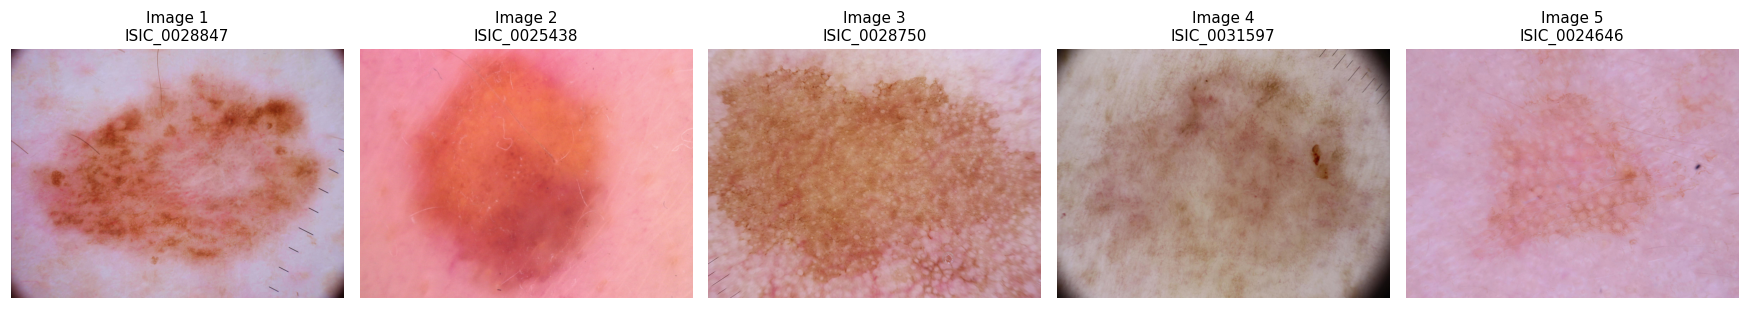

In [12]:
if meta_files:
    meta = pd.read_csv(meta_files[0])
    picks = [meta[meta.dx == d].sample(1, random_state=42).image_id.iloc[0] for d in ['mel', 'nv', 'bkl', 'bcc', 'akiec']]
else:
    picks = list(np.random.choice(list(path_map), 5, replace=False))

images = []
for i in picks:
    bgr = cv2.imread(path_map[i]); images.append(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
names = [f'Image {k+1}' for k in range(5)]
print(picks, images[0].shape)

show_row(images, [f'{n}\n{p}' for n, p in zip(names, picks)], size=3.2)

## Task 2 — Preprocess (Grayscale + Gaussian filter), Image 1

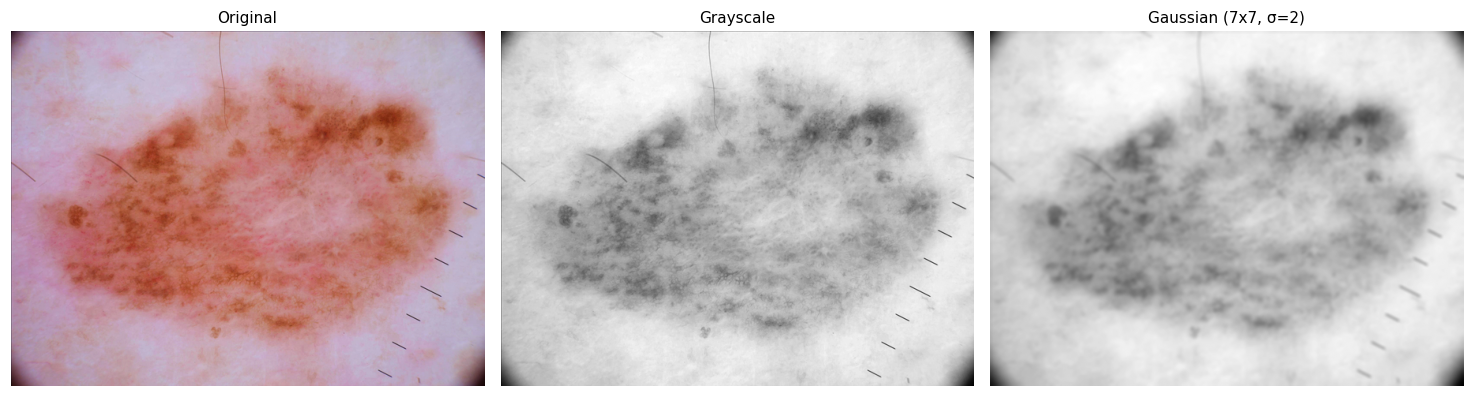

In [13]:
rgb = images[0]; gray = to_gray(rgb); gauss = f_gaussian(gray)
show_row([rgb, gray, gauss], ['Original', 'Grayscale', f'Gaussian ({K_SIZE}x{K_SIZE}, σ={G_SIGMA})'], size=4.5)

## Task 3 — Canny with three threshold settings, Image 1


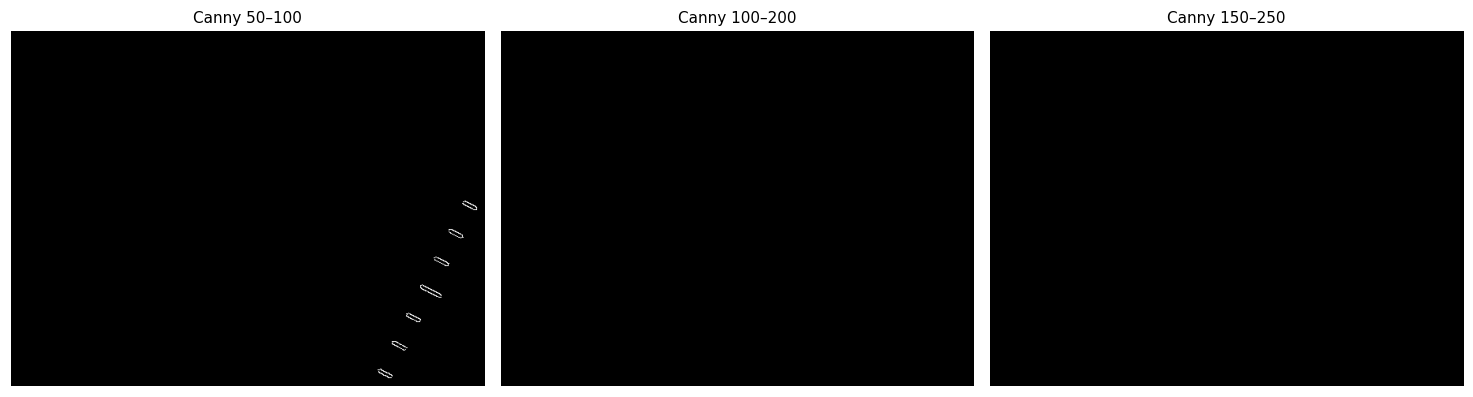

In [19]:
THRESHOLDS = [(50, 100), (100, 200), (150, 250)]
edge_maps = [canny(gauss, lo, hi) for lo, hi in THRESHOLDS]
show_row(edge_maps, [f'Canny {lo}–{hi}' for lo, hi in THRESHOLDS], size=4.5)

The suggested 50–100 / 100–200 / 150–250 returned almost no edges on the Gaussian-smoothed HAM10000 images (area = 0), so lower low/high pairs with the same low:high spacing are used: **5–15, 10–30, 30–70**.

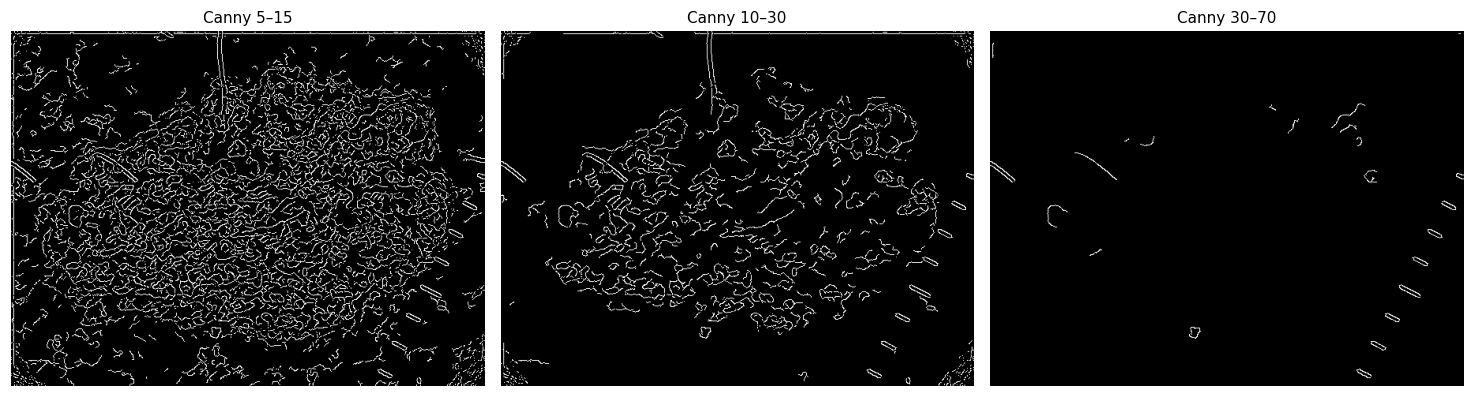

In [20]:
THRESHOLDS = [(5, 15), (10, 30), (30, 70)]
edge_maps = [canny(gauss, lo, hi) for lo, hi in THRESHOLDS]
show_row(edge_maps, [f'Canny {lo}–{hi}' for lo, hi in THRESHOLDS], size=4.5)

## Task 4 — Select the best threshold

,Threshold,edge_px,solidity,noise_ratio,score
0,5–15,27769,0.889,0.888,0.100
1,10–30,11608,0.661,0.610,0.258
2,30–70,1022,0.000,1.000,0.000


Best threshold for Image 1: (10, 30)


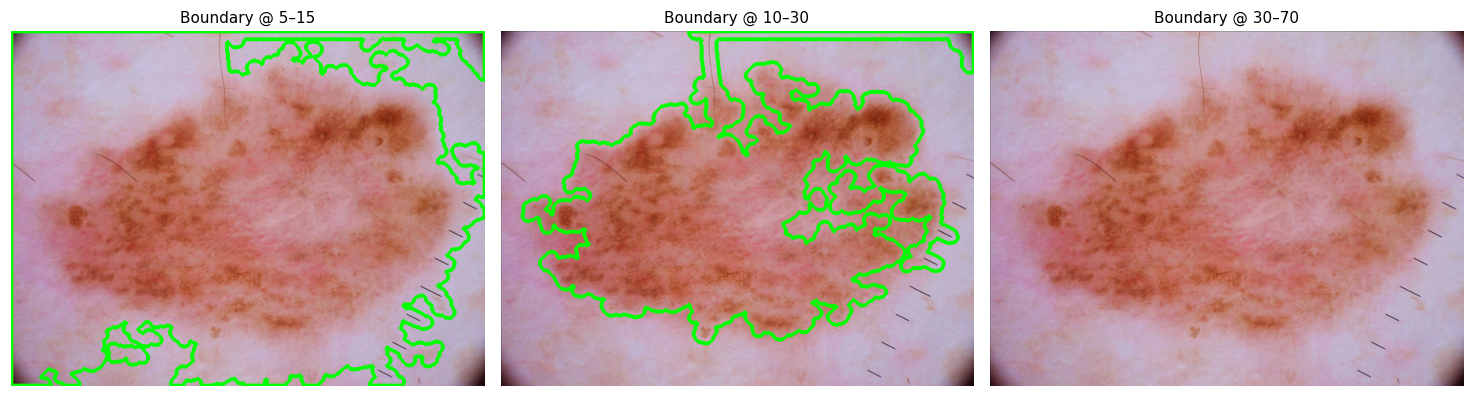

In [15]:
def score_threshold(gray_f, lo, hi):
    e = canny(gray_f, lo, hi)
    c, m = boundary_from_edges(e)
    if c is None: return e, c, m, dict(edge_px=int(np.count_nonzero(e)), solidity=0, noise_ratio=1, score=0)
    band = cv2.dilate(m, np.ones((25, 25), np.uint8)) - cv2.erode(m, np.ones((25, 25), np.uint8))
    inside_band = np.count_nonzero((e > 0) & (band > 0))
    total = max(np.count_nonzero(e), 1)
    noise = 1 - inside_band / total
    s = solidity(c)
    return e, c, m, dict(edge_px=total, solidity=round(s, 3), noise_ratio=round(noise, 3), score=round(s * (1 - noise), 3))

rows, results = [], []
for lo, hi in THRESHOLDS:
    e, c, m, d = score_threshold(gauss, lo, hi)
    results.append((e, c, m)); rows.append({'Threshold': f'{lo}–{hi}', **d})
tbl = pd.DataFrame(rows); display(tbl)

best_idx = int(tbl.score.idxmax())
print(f'Best threshold for Image 1: {THRESHOLDS[best_idx]}')
show_row([overlay(rgb, r[1]) for r in results], [f'Boundary @ {lo}–{hi}' for lo, hi in THRESHOLDS], size=4.5)

**Selection explanation (Image 1):** 
- 5-15 is too sensitive, 
- 30-70 is not detecting any edges
- 10-30 is the best in term of solidity, noice ratio, and it has the best score out of all three

## Tasks 5 & 6 — Lesion boundary, area and perimeter (full pipeline, all 5 images)
Boundary = Canny edges → morphological closing → external contour → filled mask. Area = pixels inside the mask; perimeter = contour arc length.

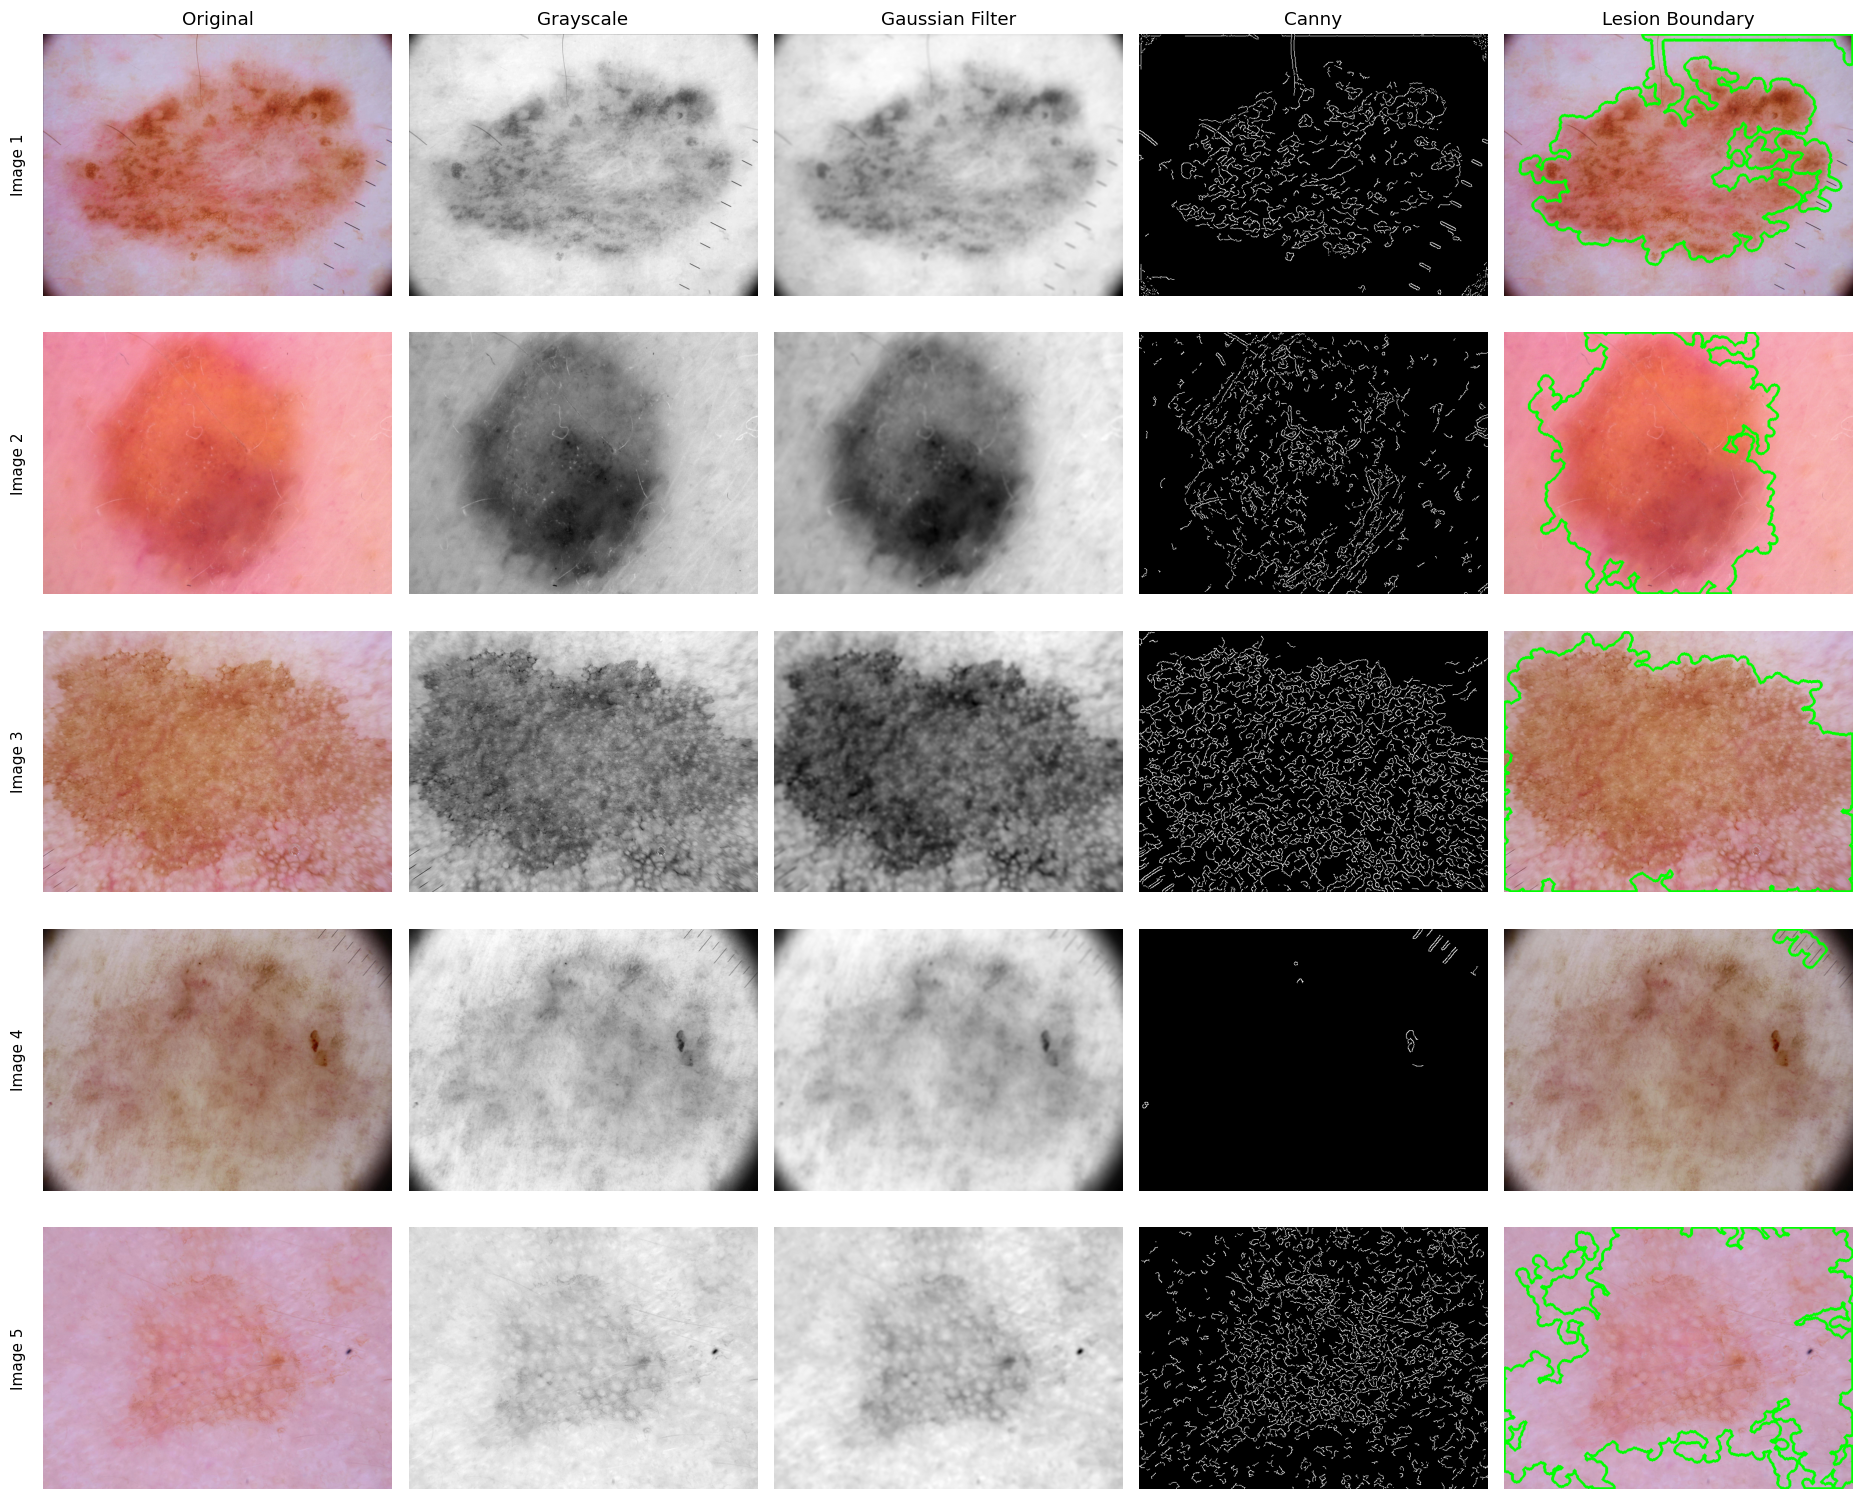

,Image,Best Filter,Edge Method,Area (pixels),Perimeter (pixels)
0,Image 1,Gaussian 7x7,Canny 10–30,119405,5175.9
1,Image 2,Gaussian 7x7,Canny 5–15,145493,3168.8
2,Image 3,Gaussian 7x7,Canny 10–30,228267,2727.9
3,Image 4,Gaussian 7x7,Canny 30–70,3079,347.4
4,Image 5,Gaussian 7x7,Canny 5–15,210206,6105.0


In [16]:
records = []
fig, axes = plt.subplots(5, 5, figsize=(17, 14))
for k, img in enumerate(images):
    g = to_gray(img); gf = f_gaussian(g)
    scored = [score_threshold(gf, lo, hi) for lo, hi in THRESHOLDS]
    bi = int(np.argmax([s[3]['score'] for s in scored]))
    e, c, m, d = scored[bi]
    area, per = measure(c, m)
    records.append({'Image': names[k], 'Best Filter': f'Gaussian {K_SIZE}x{K_SIZE}',
                    'Edge Method': f'Canny {THRESHOLDS[bi][0]}–{THRESHOLDS[bi][1]}',
                    'Area (pixels)': area, 'Perimeter (pixels)': round(per, 1)})
    for j, (im, t) in enumerate(zip([img, g, gf, e, overlay(img, c)],
                                    ['Original', 'Grayscale', 'Gaussian Filter', 'Canny', 'Lesion Boundary'])):
        axes[k, j].imshow(im, cmap=None if im.ndim == 3 else 'gray'); axes[k, j].axis('off')
        if k == 0: axes[k, j].set_title(t)
    axes[k, 0].text(-0.05, 0.5, names[k], transform=axes[k, 0].transAxes, rotation=90, va='center', ha='right')
plt.tight_layout(); plt.show()

results_df = pd.DataFrame(records); display(results_df)

## Final Comparison — Original / Average / Gaussian / Median × Sobel / Canny

In [17]:
def noise_sigma(g):
    M = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], np.float64)
    H, W = g.shape
    s = np.sum(np.abs(cv2.filter2D(g.astype(np.float64), -1, M)[1:-1, 1:-1]))
    return np.sqrt(np.pi/2) * s / (6 * (W-2) * (H-2))

def edge_f1(edges, ref_mask, tol=3):
    ref_b = cv2.morphologyEx(ref_mask, cv2.MORPH_GRADIENT, np.ones((3, 3), np.uint8))
    k = np.ones((2*tol+1, 2*tol+1), np.uint8)
    near_ref, near_edge = cv2.dilate(ref_b, k) > 0, cv2.dilate(edges, k) > 0
    P = np.count_nonzero((edges > 0) & near_ref) / max(np.count_nonzero(edges), 1)
    R = np.count_nonzero((ref_b > 0) & near_edge) / max(np.count_nonzero(ref_b), 1)
    return 2*P*R / (P+R) if P+R else 0.0

def iou(a, b):
    a, b = a > 0, b > 0
    u = np.count_nonzero(a | b); return np.count_nonzero(a & b) / u if u else 0.0

rows = []
vis = {}
for k, img in enumerate(images):
    g = to_gray(img); ref = reference_mask(g)
    for fname, ffn in FILTERS.items():
        gf = ffn(g)
        for mname in ['Sobel', 'Canny']:
            e = sobel_edges(gf) if mname == 'Sobel' else canny(gf, 10, 30)
            c, m = boundary_from_edges(e)
            rows.append({'Image': k, 'Method': f'{fname} + {mname}', 'Noise σ': noise_sigma(gf),
                         'Edge F1': edge_f1(e, ref), 'IoU': iou(m, ref)})
            if k == 0: vis[f'{fname} + {mname}'] = (e, overlay(img, c))

comp = pd.DataFrame(rows).groupby('Method', sort=False).mean(numeric_only=True).drop(columns='Image')
comp['Overall rank'] = pd.concat([comp['Noise σ'].rank(), comp['Edge F1'].rank(ascending=False),
                                  comp['IoU'].rank(ascending=False)], axis=1).mean(axis=1)
comp = comp.rename(columns={'Noise σ': 'Noise Handling (σ ↓)', 'Edge F1': 'Edge Quality (F1 ↑)', 'IoU': 'Boundary Detection (IoU ↑)'})
comp['Overall Performance'] = comp['Overall rank'].rank(method='min').astype(int)
display(comp.round(3).sort_values('Overall Performance'))

,Noise Handling (σ ↓),Edge Quality (F1 ↑),Boundary Detection (IoU ↑),Overall rank,Overall Performance
Method,,,,,
Average + Sobel,0.267,0.246,0.509,1.500,1
Gaussian + Sobel,0.271,0.237,0.516,2.167,2
Median + Sobel,0.325,0.235,0.506,3.833,3
Median + Canny,0.325,0.211,0.448,4.500,4
Gaussian + Canny,0.271,0.175,0.392,5.167,5
Average + Canny,0.267,0.138,0.279,5.833,6
Original + Canny,1.007,0.163,0.429,6.167,7
Original + Sobel,1.007,0.156,0.404,6.833,8


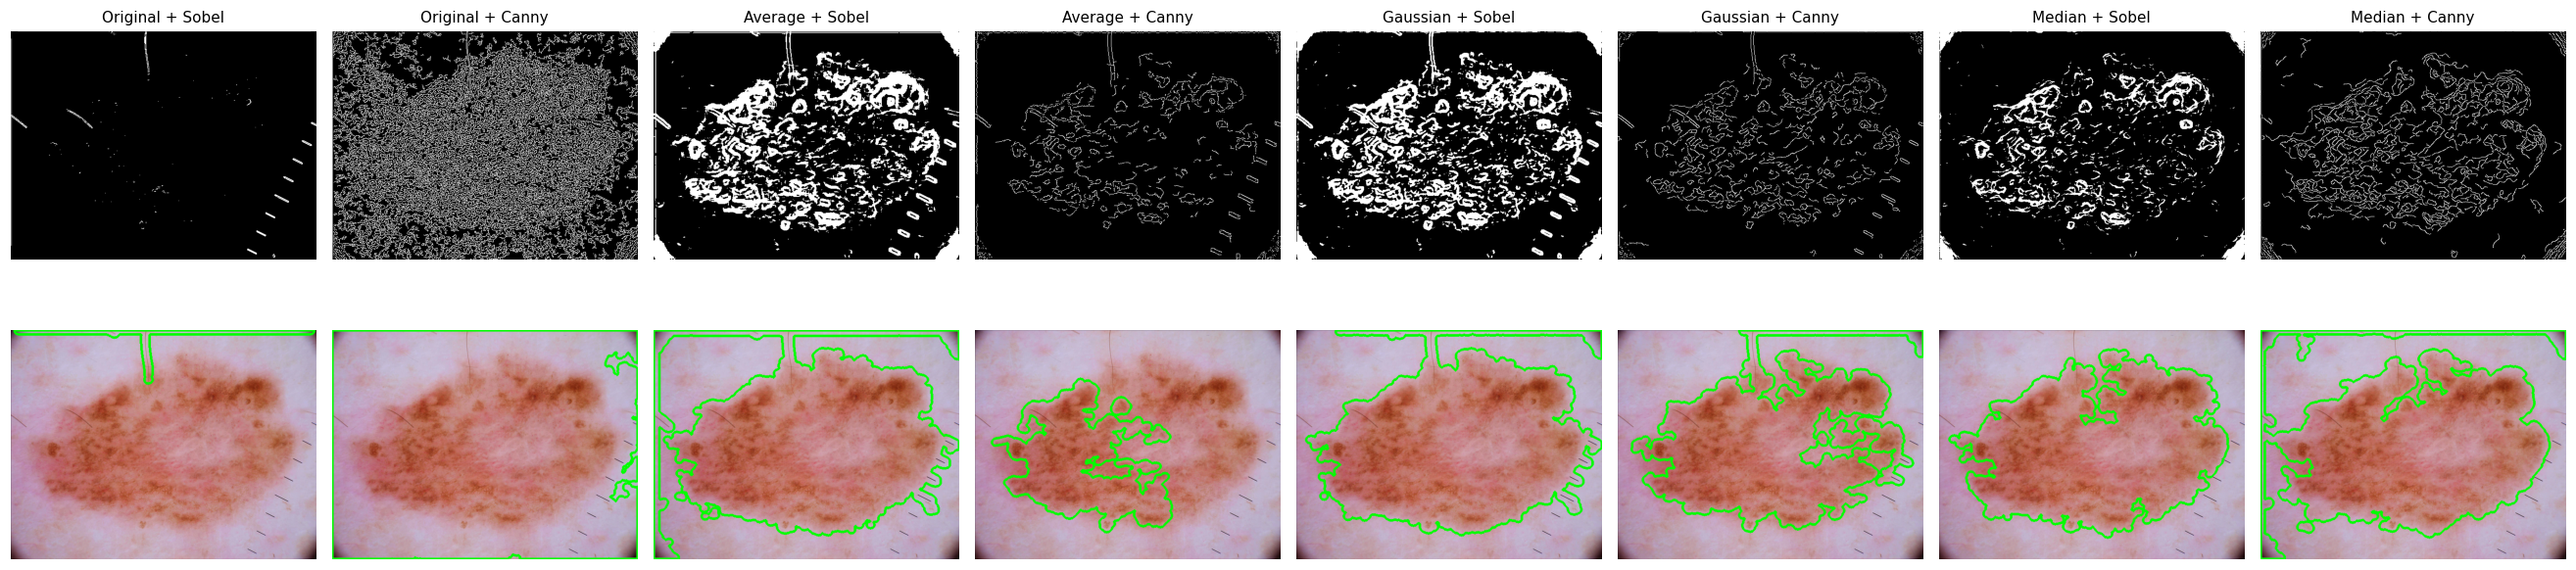

In [18]:
# Visual comparison on Image 1
fig, axes = plt.subplots(2, 8, figsize=(24, 6.5))
for j, (name, (e, ov)) in enumerate(vis.items()):
    axes[0, j].imshow(e, cmap='gray'); axes[0, j].set_title(name, fontsize=10); axes[0, j].axis('off')
    axes[1, j].imshow(ov); axes[1, j].axis('off')
plt.tight_layout(); plt.show()

## Questions

**1. Why is Gaussian filtering applied before Canny detection?**
Canny relies on image gradients, which amplify noise. Gaussian smoothing suppresses sensor noise, fine skin texture and thin hairs so that only strong, meaningful intensity transitions survive gradient computation, and it avoids the blocky/shifted edges that average filtering can produce.

**2. How did the three Canny threshold settings affect the result?**
Low thresholds (5–15) keep many weak edges → texture, hair and vignette noise, with a cluttered boundary. High thresholds (30–70) keep only the strongest edges → cleaner map but gaps in low-contrast parts of the border. The middle setting (10–30) balances both. (The originally suggested 50–100 / 100–200 / 150–250 were too high for the smoothed images and returned little or no edge.)

**3. Which threshold produced the best lesion boundary?**
10-30 gave the highest solidity × (1 − noise ratio) and the most continuous closed contour.

**4. Why are edges useful for detecting skin lesions?**
Lesions differ from surrounding skin in pigment/intensity, so their border appears as a strong, closed intensity transition. Edges give a compact representation of that border, from which shape descriptors (area, perimeter, irregularity) used in ABCD-style dermatology analysis can be computed.

**5. Problems observed**
Hair and air bubbles create false edges; low-contrast or fuzzy lesion borders produce gaps; the dark circular vignette in dermoscopy images creates a strong edge; uneven pigmentation inside the lesion creates internal edges; gaps require morphological closing, which can slightly over-/under-estimate the area.

**6. How could the method be improved?**
Hair removal (DullRazor/black-hat + inpainting); illumination correction and vignette cropping; colour-space (e.g., Lab / saturation channel) edges instead of grayscale; automatic/adaptive Canny thresholds (Otsu-based or median-based); active contours / watershed / GrabCut refinement; or a learned segmenter such as U-Net trained on ISIC/HAM10000 masks.